# Phase 3 v9 - Two-Stage Model Training with Class Merging & Threshold Tuning

### What changed from v8

Phase 3 v8 achieved 75.7% combined accuracy and 0.474 macro F1. Analysis of the
Stage 2 confusion matrix revealed two clear confusion clusters:

| Confusion pair | Why they confuse | Physical overlap |
|---------------|-----------------|-----------------|
| `leaning_to_neighbor` ↔ `passing_note` | Both involve torso shifting / arm extending toward a neighbour | Torso lean + wrist extent features overlap |
| `looking_sideways` ↔ `talking_to_neighbor` | Both involve turning the head toward a neighbour | Head turn + ear asymmetry features overlap; mouth keypoints too noisy to distinguish |



---

## 1. Setup & Dependencies

In [1]:
#  Dependency check

import subprocess, sys

def _safe_install(pkg):
    """Install a package only if it cannot be imported."""
    mod = pkg.split('==')[0].replace('-', '_')
    try:
        __import__(mod)
    except ImportError:
        subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', pkg])

_safe_install('torch')
_safe_install('seaborn')

print('Dependencies OK.')

Dependencies OK.


In [2]:
# Imports
import os
import io
import json
import pickle
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset, WeightedRandomSampler

from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    accuracy_score,
    f1_score,
    precision_recall_curve,
)

warnings.filterwarnings('ignore')
sns.set_style('whitegrid')

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {device}')
print(f'PyTorch: {torch.__version__}')

Device: cuda
PyTorch: 2.6.0


---

## 2. Configuration

### Class merge mapping

The merge mapping converts the original 5 suspicious class names into 3 merged
class names. This is applied to the label arrays after loading the Phase 2 checkpoint.

| Original class | Merged class | Rationale |
|---------------|-------------|-----------|
| `looking_down` | `looking_down` | Already 97% recall; clean signal from nose-shoulder distance |
| `leaning_to_neighbor` | `lateral_movement` | Both involve torso shift / arm extension toward neighbour |
| `passing_note` | `lateral_movement` | Physically similar to leaning; torso lean + wrist extent features overlap |
| `looking_sideways` | `head_turn` | Both involve head rotation; ear asymmetry + head turn features overlap |
| `talking_to_neighbor` | `head_turn` | Same head turn signal; mouth keypoints too noisy at this camera distance |


In [3]:
# CONFIGURATION

DATA_DIR   = '/home/sagemaker-user/exam_proctoring_dataset'
OUTPUT_DIR = os.path.join(DATA_DIR, 'training_outputs')
os.makedirs(OUTPUT_DIR, exist_ok=True)

# Phase 2 checkpoint candidates (tried in order)
FEATURES_CHECKPOINT_CANDIDATES = [
    os.path.join(OUTPUT_DIR, 'features_v10_checkpoint_filtered.pkl'),
    os.path.join(OUTPUT_DIR, 'features_v10_checkpoint.pkl'),
    os.path.join(OUTPUT_DIR, 'features_v9_manual_clip_only_target_review_checkpoint.pkl'),
]

# Output paths
S1_MODEL_PATH      = os.path.join(OUTPUT_DIR, 'stage1_best_v9.pth')
S1_SCALER_PATH     = os.path.join(OUTPUT_DIR, 'stage1_scaler_v9.pkl')
S2_MODEL_PATH      = os.path.join(OUTPUT_DIR, 'stage2_best_v9.pth')
S2_SCALER_PATH     = os.path.join(OUTPUT_DIR, 'stage2_scaler_v9.pkl')
INFERENCE_PKG_PATH = os.path.join(OUTPUT_DIR, 'inference_package_v9.pth')

# Review CSV candidates (for exclusion filtering)

REVIEW_CSV_CANDIDATES = [
    os.path.join(DATA_DIR, 'review_target_person_v10', 'target_person_review.csv'),
    os.path.join(DATA_DIR, 'review_target_person_v9',  'target_person_review.csv'),
]


# Model hyperparameters
H1     = 128    # First hidden layer neurons
H2     = 64     # Second hidden layer neurons
DROP   = 0.4    # Dropout — increased from 0.3 to reduce Stage 2 overfitting
LR     = 1e-3   # Adam learning rate
BS     = 64     # Batch size
EPOCHS = 150    # Max training epochs
PAT    = 25     # Early stopping patience — increased from 20 (3 classes converge slower)

# Class merge mapping
# Maps original 5 suspicious classes → 3 merged classes.
# Applied to the 6-class label array (normal stays normal).
MERGE_MAP = {
    'normal':               'normal',
    'looking_down':         'looking_down',
    'leaning_to_neighbor':  'lateral_movement',
    'passing_note':         'lateral_movement',
    'looking_sideways':     'head_turn',
    'talking_to_neighbor':  'head_turn',
}

# The 3 merged suspicious class names (alphabetical order for LabelEncoder)
MERGED_SUSPICIOUS = sorted(set(
    v for k, v in MERGE_MAP.items() if v != 'normal'
))
# Result: ['head_turn', 'lateral_movement', 'looking_down']

ALL_MERGED_CLASSES = ['normal'] + MERGED_SUSPICIOUS
NUM_MERGED_SUS     = len(MERGED_SUSPICIOUS)  # 3

# Reverse mapping: for inference package documentation
MERGE_REVERSE = {}
for orig, merged in MERGE_MAP.items():
    if merged != 'normal':
        MERGE_REVERSE.setdefault(merged, []).append(orig)

# Stage 1 threshold sweep range

# We'll evaluate P(suspicious) thresholds from 0.20 to 0.80 in steps of 0.02.
# The optimal threshold maximises a recall-weighted F1 on the validation set.
THRESHOLD_SWEEP = np.arange(0.20, 0.82, 0.02)
DEFAULT_THRESHOLD = 0.50  # argmax-equivalent baseline

# Reproducibility
SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

# Utility functions

def save_ckpt(obj, path):
    """Pickle an object to disk."""
    with open(path, 'wb') as f:
        pickle.dump(obj, f)
    print(f'  Saved: {os.path.basename(path)} ({os.path.getsize(path)/1024:.1f} KB)')

def load_ckpt(path):
    """Load a pickle file if it exists."""
    if not os.path.exists(path):
        return None
    with open(path, 'rb') as f:
        obj = pickle.load(f)
    print(f'  Loaded: {os.path.basename(path)}')
    return obj

def scaler_to_bytes(scaler):
    """Serialise a sklearn scaler to bytes for embedding in a .pth file."""
    buf = io.BytesIO()
    pickle.dump(scaler, buf)
    return buf.getvalue()

# Print configuration summary
print('Configuration ready.')
print(f'  DATA_DIR:         {DATA_DIR}')
print(f'  Merge mapping:    {MERGE_MAP}')
print(f'  Merged classes:   {ALL_MERGED_CLASSES}')
print(f'  Original → merged:')
for merged, originals in sorted(MERGE_REVERSE.items()):
    print(f'    {merged}: {originals}')
print(f'  Model: Input → {H1} → {H2} → Output  (drop={DROP})')
print(f'  Threshold sweep: {THRESHOLD_SWEEP[0]:.2f} to {THRESHOLD_SWEEP[-1]:.2f}')

Configuration ready.
  DATA_DIR:         /home/sagemaker-user/exam_proctoring_dataset
  Merge mapping:    {'normal': 'normal', 'looking_down': 'looking_down', 'leaning_to_neighbor': 'lateral_movement', 'passing_note': 'lateral_movement', 'looking_sideways': 'head_turn', 'talking_to_neighbor': 'head_turn'}
  Merged classes:   ['normal', 'head_turn', 'lateral_movement', 'looking_down']
  Original → merged:
    head_turn: ['looking_sideways', 'talking_to_neighbor']
    lateral_movement: ['leaning_to_neighbor', 'passing_note']
    looking_down: ['looking_down']
  Model: Input → 128 → 64 → Output  (drop=0.4)
  Threshold sweep: 0.20 to 0.80


---

## 3. Load Phase 2 Feature Checkpoint

Same loading logic as v8 - tries multiple checkpoint candidates in order.

In [4]:
# Load Phase 2 checkpoint

cached = None
loaded_path = None

for candidate in FEATURES_CHECKPOINT_CANDIDATES:
    if os.path.exists(candidate):
        cached = load_ckpt(candidate)
        loaded_path = candidate
        break

if cached is None:
    raise FileNotFoundError(
        'No Phase 2 checkpoint found. Run Phase 2 first.\n'
        'Searched:\n  ' + '\n  '.join(FEATURES_CHECKPOINT_CANDIDATES)
    )

# Unpack
all_features = cached['features']           # (N, 78) float32
all_labels_7 = cached['labels_7class']      # (N,) str — original 6-class labels
all_labels_2 = cached['labels_binary']      # (N,) str — 'normal' or 'suspicious'
all_meta     = cached['meta']               # list of N dicts
FEAT_NAMES      = cached['feature_names']
FULL_FEAT_NAMES = cached['full_feature_names']
NUM_FEATURES    = all_features.shape[1]     # 78

# Sanity checks
assert all_features.shape[0] == len(all_labels_7) == len(all_meta)
assert NUM_FEATURES == len(FULL_FEAT_NAMES)
assert 'using_phone' not in set(np.unique(all_labels_7)), 'Checkpoint contains using_phone!'

print(f'\nCheckpoint: {os.path.basename(loaded_path)}')
print(f'Windows: {len(all_features):,}, Features: {NUM_FEATURES}')
print(f'\nOriginal 6-class distribution:')
for l, c in zip(*np.unique(all_labels_7, return_counts=True)):
    print(f'  {l:<25s} {c:5d}  ({c/len(all_labels_7)*100:.1f}%)')

  Loaded: features_v9_manual_clip_only_target_review_checkpoint.pkl

Checkpoint: features_v9_manual_clip_only_target_review_checkpoint.pkl
Windows: 3,496, Features: 78

Original 6-class distribution:
  leaning_to_neighbor         299  (8.6%)
  looking_down                199  (5.7%)
  looking_sideways            279  (8.0%)
  normal                     2381  (68.1%)
  passing_note                105  (3.0%)
  talking_to_neighbor         233  (6.7%)


---

## 4. Apply Review Exclusions


In [6]:
# Apply review exclusions

excluded_keys = set()

for candidate in REVIEW_CSV_CANDIDATES:
    if not os.path.exists(candidate):
        continue
    try:
        review_df = pd.read_csv(candidate, encoding='utf-8-sig')
        if 'review_status' in review_df.columns:
            status = review_df['review_status'].fillna('').astype(str).str.strip().str.lower()
            for _, row in review_df[status == 'exclude'].iterrows():
                excluded_keys.add((str(row['clip_stem']).strip(), int(row['window_index'])))
            if excluded_keys:
                print(f'  Loaded {len(excluded_keys)} exclusions from: {os.path.basename(candidate)}')
            else:
                print(f'  Review CSV loaded — no exclusions marked.')
        break
    except Exception as e:
        print(f'  Warning: could not read {candidate}: {e}')

n_before = len(all_features)
if excluded_keys:
    keep = np.ones(n_before, dtype=bool)
    for i, m in enumerate(all_meta):
        if (str(m['clip_stem']).strip(), int(m['window_index'])) in excluded_keys:
            keep[i] = False
    n_removed = int((~keep).sum())
    if n_removed > 0:
        all_features = all_features[keep]
        all_labels_7 = all_labels_7[keep]
        all_labels_2 = all_labels_2[keep]
        all_meta = [m for m, k in zip(all_meta, keep) if k]
        print(f'  Removed {n_removed} windows. Remaining: {len(all_features)}')

if not excluded_keys:
    print('  No exclusions to apply.')

print(f'\nPost-exclusion: {len(all_features)} windows')

  Loaded 130 exclusions from: target_person_review.csv
  Removed 130 windows. Remaining: 3366

Post-exclusion: 3366 windows


---

## 5. Apply Class Merging

In [7]:
# Apply class merging to label arrays

# Create the merged label array by mapping each original label
all_labels_merged = np.array([MERGE_MAP[label] for label in all_labels_7])

# Verify the mapping worked
print('Class merge applied:')
print(f'\n  Original 6-class distribution:')
for l, c in zip(*np.unique(all_labels_7, return_counts=True)):
    mapped = MERGE_MAP.get(l, l)
    print(f'    {l:<25s} {c:5d}  → {mapped}')

print(f'\n  Merged 4-class distribution:')
for l, c in zip(*np.unique(all_labels_merged, return_counts=True)):
    pct = c / len(all_labels_merged) * 100
    bar = '█' * int(pct / 2)
    print(f'    {l:<20s} {c:5d}  ({pct:5.1f}%)  {bar}')

# Verify binary labels still match
merged_sus = all_labels_merged != 'normal'
binary_sus = all_labels_2 == 'suspicious'
assert np.array_equal(merged_sus, binary_sus), 'Binary/merged label mismatch!'
print(f'\n  Binary consistency check: PASSED')
print(f'  Normal: {(~merged_sus).sum()}, Suspicious: {merged_sus.sum()}')

Class merge applied:

  Original 6-class distribution:
    leaning_to_neighbor         277  → lateral_movement
    looking_down                182  → looking_down
    looking_sideways            253  → head_turn
    normal                     2324  → normal
    passing_note                 97  → lateral_movement
    talking_to_neighbor         233  → head_turn

  Merged 4-class distribution:
    head_turn              486  ( 14.4%)  ███████
    lateral_movement       374  ( 11.1%)  █████
    looking_down           182  (  5.4%)  ██
    normal                2324  ( 69.0%)  ██████████████████████████████████

  Binary consistency check: PASSED
  Normal: 2324, Suspicious: 1042


---

## 6. Stratified Scenario-Level Split


In [8]:
# Stratified scenario-level split

def stratified_scenario_split(meta_list, seed=SEED):
    """Split scenarios into train/val/test, stratified by ORIGINAL behaviour class."""
    rng = np.random.default_rng(seed)
    meta_df = pd.DataFrame(meta_list)
    scenario_df = meta_df[['scenario_id', 'original_behavior']].drop_duplicates()

    train_ids, val_ids, test_ids = [], [], []

    for cls in sorted(scenario_df['original_behavior'].unique()):
        cls_scenarios = scenario_df.loc[
            scenario_df['original_behavior'] == cls, 'scenario_id'
        ].unique().tolist()
        rng.shuffle(cls_scenarios)
        n = len(cls_scenarios)

        if n < 3:
            raise ValueError(f"Class '{cls}' has only {n} scenarios — need ≥3.")

        n_test  = max(1, round(n * 0.15))
        n_val   = max(1, round(n * 0.15))
        n_train = n - n_val - n_test

        while n_train < 1:
            if n_test > n_val and n_test > 1:
                n_test -= 1
            elif n_val > 1:
                n_val -= 1
            else:
                break
            n_train = n - n_val - n_test

        train_ids.extend(cls_scenarios[:n_train])
        val_ids.extend(cls_scenarios[n_train:n_train + n_val])
        test_ids.extend(cls_scenarios[n_train + n_val:])

    return set(train_ids), set(val_ids), set(test_ids)


train_scenarios, val_scenarios, test_scenarios = stratified_scenario_split(all_meta)

meta_df = pd.DataFrame(all_meta)
tr_m = meta_df['scenario_id'].isin(train_scenarios).values
va_m = meta_df['scenario_id'].isin(val_scenarios).values
te_m = meta_df['scenario_id'].isin(test_scenarios).values

assert (tr_m | va_m | te_m).all(), 'Unassigned windows!'
assert not (tr_m & va_m).any() and not (tr_m & te_m).any(), 'Overlap!'

print(f'Split sizes:')
print(f'  Train: {tr_m.sum():5d}')
print(f'  Val:   {va_m.sum():5d}')
print(f'  Test:  {te_m.sum():5d}')

# Show merged class coverage per split
print(f'\nMerged class counts per split:')
for name, mask in [('Train', tr_m), ('Val', va_m), ('Test', te_m)]:
    counts = pd.Series(all_labels_merged[mask]).value_counts().sort_index()
    print(f'  {name}:')
    for cls, cnt in counts.items():
        print(f'    {cls:<20s} {cnt:4d}')

Split sizes:
  Train:  2234
  Val:     557
  Test:    575

Merged class counts per split:
  Train:
    head_turn             345
    lateral_movement      265
    looking_down          122
    normal               1502
  Val:
    head_turn              71
    lateral_movement       49
    looking_down           27
    normal                410
  Test:
    head_turn              70
    lateral_movement       60
    looking_down           33
    normal                412


---

## 7. Model Architecture & Training Function

Same MLP architecture as v8, but with dropout increased from 0.3 to 0.4
to reduce the Stage 2 overfitting observed in v8 (train F1 0.96 vs val F1 0.66).

In [9]:
# Classifier model

class Classifier(nn.Module):
    """Two-hidden-layer MLP with BatchNorm and Dropout."""

    def __init__(self, input_dim, hidden1, hidden2, num_classes, dropout=0.3):
        super().__init__()
        self.net = nn.Sequential(
            nn.BatchNorm1d(input_dim),
            nn.Linear(input_dim, hidden1),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.BatchNorm1d(hidden1),
            nn.Linear(hidden1, hidden2),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden2, num_classes),
        )

    def forward(self, x):
        return self.net(x)

In [10]:
# Training function

def train_model(model, train_dl, val_dl, num_classes, save_path,
                max_epochs=EPOCHS, patience=PAT):
    """Train with weighted CE loss, Adam, ReduceLROnPlateau, and early stopping."""

    # Class weights from training distribution
    cc = np.zeros(num_classes)
    for _, yb in train_dl:
        for y in yb.numpy():
            cc[y] += 1
    cw = 1.0 / np.maximum(cc, 1)
    cw = cw / cw.sum() * num_classes
    criterion = nn.CrossEntropyLoss(weight=torch.FloatTensor(cw).to(device))

    optimizer = optim.Adam(model.parameters(), lr=LR, weight_decay=1e-4)
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, mode='max', factor=0.5, patience=10, verbose=False
    )

    hist = {'t_loss': [], 'v_loss': [], 't_f1': [], 'v_f1': []}
    best_f1 = 0.0
    pat_ctr = 0

    for ep in range(max_epochs):
        # Train
        model.train()
        tl, tp, tt = [], [], []
        for xb, yb in train_dl:
            xb, yb = xb.to(device), yb.to(device)
            optimizer.zero_grad()
            out = model(xb)
            loss = criterion(out, yb)
            loss.backward()
            optimizer.step()
            tl.append(loss.item())
            tp.extend(out.argmax(1).cpu().numpy())
            tt.extend(yb.cpu().numpy())

        # Validate
        model.eval()
        vl, vp, vt = [], [], []
        with torch.no_grad():
            for xb, yb in val_dl:
                xb, yb = xb.to(device), yb.to(device)
                out = model(xb)
                loss = criterion(out, yb)
                vl.append(loss.item())
                vp.extend(out.argmax(1).cpu().numpy())
                vt.extend(yb.cpu().numpy())

        t_f1 = f1_score(tt, tp, average='macro', zero_division=0)
        v_f1 = f1_score(vt, vp, average='macro', zero_division=0)
        hist['t_loss'].append(float(np.mean(tl)))
        hist['v_loss'].append(float(np.mean(vl)))
        hist['t_f1'].append(float(t_f1))
        hist['v_f1'].append(float(v_f1))
        scheduler.step(v_f1)

        improved = ''
        if v_f1 > best_f1:
            best_f1 = v_f1
            pat_ctr = 0
            improved = '  ★'
            torch.save({'state_dict': model.state_dict(), 'epoch': ep, 'val_f1': v_f1}, save_path)
        else:
            pat_ctr += 1

        if (ep + 1) % 10 == 0 or ep == 0 or improved:
            lr_now = optimizer.param_groups[0]['lr']
            print(f'  Ep {ep+1:3d}/{max_epochs}  '
                  f'loss={np.mean(tl):.4f}/{np.mean(vl):.4f}  '
                  f'F1={t_f1:.4f}/{v_f1:.4f}  lr={lr_now:.1e}{improved}')

        if pat_ctr >= patience:
            print(f'  Early stopping at epoch {ep+1}')
            break

    print(f'  Best val F1: {best_f1:.4f}')
    return hist, best_f1


def plot_curves(hist, title, save_name):
    """Plot loss and F1 training curves."""
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    axes[0].plot(hist['t_loss'], label='Train', color='steelblue', lw=1.5)
    axes[0].plot(hist['v_loss'], label='Val', color='coral', lw=1.5)
    axes[0].set_title(f'{title} — Loss'); axes[0].legend(); axes[0].grid(True, alpha=0.3)
    axes[0].set_xlabel('Epoch')
    axes[1].plot(hist['t_f1'], label='Train', color='steelblue', lw=1.5)
    axes[1].plot(hist['v_f1'], label='Val', color='coral', lw=1.5)
    axes[1].set_title(f'{title} — Macro F1'); axes[1].legend(); axes[1].grid(True, alpha=0.3)
    axes[1].set_xlabel('Epoch'); axes[1].set_ylim(0, 1.05)
    plt.tight_layout()
    plt.savefig(os.path.join(OUTPUT_DIR, save_name), dpi=150, bbox_inches='tight')
    plt.show()

print('Model and training function defined.')

Model and training function defined.


---

## 8. Stage 1 - Binary Classifier (Normal vs Suspicious)


In [11]:
# Prepare Stage 1 data

le1 = LabelEncoder()
le1.fit(['normal', 'suspicious'])
y1_all = le1.transform(all_labels_2)

sc1 = StandardScaler()
X1_tr = sc1.fit_transform(all_features[tr_m]).astype(np.float32)
X1_va = sc1.transform(all_features[va_m]).astype(np.float32)
X1_te = sc1.transform(all_features[te_m]).astype(np.float32)
y1_tr, y1_va, y1_te = y1_all[tr_m], y1_all[va_m], y1_all[te_m]

save_ckpt(sc1, S1_SCALER_PATH)

n_nor = int((y1_tr == 0).sum())
n_sus = int((y1_tr == 1).sum())
print(f'\nStage 1 train: normal={n_nor}, suspicious={n_sus}, ratio={n_nor/max(n_sus,1):.1f}:1')

cc1 = np.bincount(y1_tr, minlength=2).astype(np.float64)
sw1 = (1.0 / np.maximum(cc1, 1))[y1_tr]
sw1 = sw1 / sw1.sum()
sampler1 = WeightedRandomSampler(sw1, len(sw1), replacement=True)

dl1_tr = DataLoader(TensorDataset(torch.FloatTensor(X1_tr), torch.LongTensor(y1_tr)), batch_size=BS, sampler=sampler1)
dl1_va = DataLoader(TensorDataset(torch.FloatTensor(X1_va), torch.LongTensor(y1_va)), batch_size=BS, shuffle=False)
dl1_te = DataLoader(TensorDataset(torch.FloatTensor(X1_te), torch.LongTensor(y1_te)), batch_size=BS, shuffle=False)

  Saved: stage1_scaler_v9.pkl (2.3 KB)

Stage 1 train: normal=1502, suspicious=732, ratio=2.1:1


In [12]:
# Train Stage 1
print('=' * 60)
print('  STAGE 1: Normal vs Suspicious')
print('=' * 60)

model1 = Classifier(NUM_FEATURES, H1, H2, 2, DROP).to(device)
print(f'  Parameters: {sum(p.numel() for p in model1.parameters()):,}\n')

hist1, best_f1_s1 = train_model(model1, dl1_tr, dl1_va, 2, S1_MODEL_PATH)

  STAGE 1: Normal vs Suspicious
  Parameters: 18,910

  Ep   1/150  loss=0.6150/0.5495  F1=0.6624/0.6769  lr=1.0e-03  ★
  Ep   2/150  loss=0.4797/0.5243  F1=0.7842/0.6827  lr=1.0e-03  ★
  Ep   3/150  loss=0.4361/0.5626  F1=0.8057/0.7118  lr=1.0e-03  ★
  Ep   4/150  loss=0.3830/0.5334  F1=0.8405/0.7338  lr=1.0e-03  ★
  Ep   6/150  loss=0.3117/0.5528  F1=0.8657/0.7364  lr=1.0e-03  ★
  Ep   7/150  loss=0.3170/0.5062  F1=0.8647/0.7494  lr=1.0e-03  ★
  Ep   8/150  loss=0.3197/0.4974  F1=0.8627/0.7511  lr=1.0e-03  ★
  Ep   9/150  loss=0.2789/0.5006  F1=0.8778/0.7561  lr=1.0e-03  ★
  Ep  10/150  loss=0.2804/0.4949  F1=0.8822/0.7700  lr=1.0e-03  ★
  Ep  12/150  loss=0.2697/0.5134  F1=0.8819/0.7837  lr=1.0e-03  ★
  Ep  14/150  loss=0.2300/0.4855  F1=0.9072/0.7885  lr=1.0e-03  ★
  Ep  15/150  loss=0.2348/0.4783  F1=0.9023/0.7942  lr=1.0e-03  ★
  Ep  17/150  loss=0.2116/0.4860  F1=0.9151/0.7980  lr=1.0e-03  ★
  Ep  18/150  loss=0.2110/0.4754  F1=0.9123/0.8033  lr=1.0e-03  ★
  Ep  19/150  loss=0.2

### Stage 1 - Training Curves

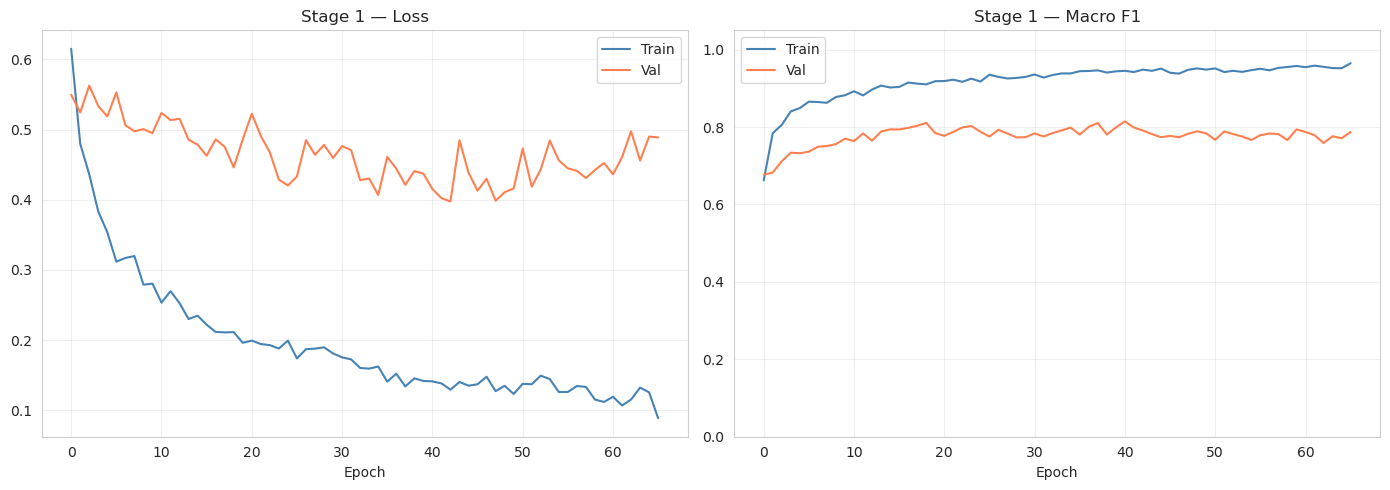

In [13]:
plot_curves(hist1, 'Stage 1', 'v9_stage1_curves.png')

---

## 9. Stage 1 Threshold Optimization

Instead of using `argmax` (P > 0.5), we sweep probability thresholds and find
the one that gives the best trade-off between suspicious recall and overall F1.

### Why lower the threshold?

In v8, Stage 1 missed 41.7% of suspicious windows (recall = 0.583). For a
proctoring system, a missed cheater is worse than a false alarm. Lowering the
threshold means:
- **More suspicious windows flagged** → higher recall → fewer missed cheaters
- **More false positives** → but these are reviewed by the proctor, who can dismiss them


In [14]:
# Threshold optimization on validation set

# Load best Stage 1 model
ckpt1 = torch.load(S1_MODEL_PATH, map_location=device, weights_only=True)
model1.load_state_dict(ckpt1['state_dict'])
print(f'Loaded Stage 1 from epoch {ckpt1["epoch"]+1} (val F1 = {ckpt1["val_f1"]:.4f})')

# Get softmax probabilities on validation set
model1.eval()
val_probs, val_trues = [], []
with torch.no_grad():
    for xb, yb in dl1_va:
        logits = model1(xb.to(device))
        probs = torch.softmax(logits, dim=1)
        val_probs.append(probs.cpu().numpy())
        val_trues.extend(yb.numpy())
val_probs = np.vstack(val_probs)       # (N_val, 2) — col 0=P(normal), col 1=P(suspicious)
val_trues = np.array(val_trues)         # (N_val,) — 0=normal, 1=suspicious
p_sus_val = val_probs[:, 1]             # P(suspicious) for each validation window

# Also get probabilities on test set (for final evaluation)
test_probs, test_trues = [], []
with torch.no_grad():
    for xb, yb in dl1_te:
        logits = model1(xb.to(device))
        probs = torch.softmax(logits, dim=1)
        test_probs.append(probs.cpu().numpy())
        test_trues.extend(yb.numpy())
test_probs = np.vstack(test_probs)
test_trues = np.array(test_trues)
p_sus_te = test_probs[:, 1]

# Sweep thresholds on validation set

results = []
for thr in THRESHOLD_SWEEP:
    preds = (p_sus_val >= thr).astype(int)
    acc = accuracy_score(val_trues, preds)
    f1  = f1_score(val_trues, preds, average='macro', zero_division=0)

    # F-beta (beta=2): weights recall 2x more than precision
    prec = float((preds[val_trues == 1] == 1).sum()) / max(float((preds == 1).sum()), 1)
    rec  = float((preds[val_trues == 1] == 1).sum()) / max(float((val_trues == 1).sum()), 1)
    fbeta = (1 + 4) * prec * rec / max((4 * prec + rec), 1e-6)  # beta=2 → beta²=4

    results.append({
        'threshold': float(thr),
        'accuracy': acc,
        'macro_f1': f1,
        'precision': prec,
        'recall': rec,
        'f_beta2': fbeta,
        'n_flagged': int(preds.sum()),
        'n_total': len(preds),
    })

res_df = pd.DataFrame(results)

# Find optimal thresholds
best_f1_row   = res_df.loc[res_df['macro_f1'].idxmax()]
best_fb2_row  = res_df.loc[res_df['f_beta2'].idxmax()]
default_row   = res_df.loc[(res_df['threshold'] - DEFAULT_THRESHOLD).abs().idxmin()]

print(f'\nThreshold sweep results (validation set):')
print(f'\n  Default (0.50):  F1={default_row["macro_f1"]:.4f}  recall={default_row["recall"]:.4f}  prec={default_row["precision"]:.4f}')
print(f'  Best macro F1:   thr={best_f1_row["threshold"]:.2f}  F1={best_f1_row["macro_f1"]:.4f}  recall={best_f1_row["recall"]:.4f}  prec={best_f1_row["precision"]:.4f}')
print(f'  Best F-beta(2):  thr={best_fb2_row["threshold"]:.2f}  F1={best_fb2_row["macro_f1"]:.4f}  recall={best_fb2_row["recall"]:.4f}  prec={best_fb2_row["precision"]:.4f}')

# Select the optimal threshold: use F-beta(2) for proctoring (recall-weighted)
OPTIMAL_THRESHOLD = float(best_fb2_row['threshold'])
print(f'\n  ► Selected threshold: {OPTIMAL_THRESHOLD:.2f} (F-beta2 optimised, recall-weighted)')

Loaded Stage 1 from epoch 41 (val F1 = 0.8147)

Threshold sweep results (validation set):

  Default (0.50):  F1=0.8147  recall=0.8095  prec=0.6761
  Best macro F1:   thr=0.50  F1=0.8147  recall=0.8095  prec=0.6761
  Best F-beta(2):  thr=0.26  F1=0.7954  recall=0.8912  prec=0.6093

  ► Selected threshold: 0.26 (F-beta2 optimised, recall-weighted)


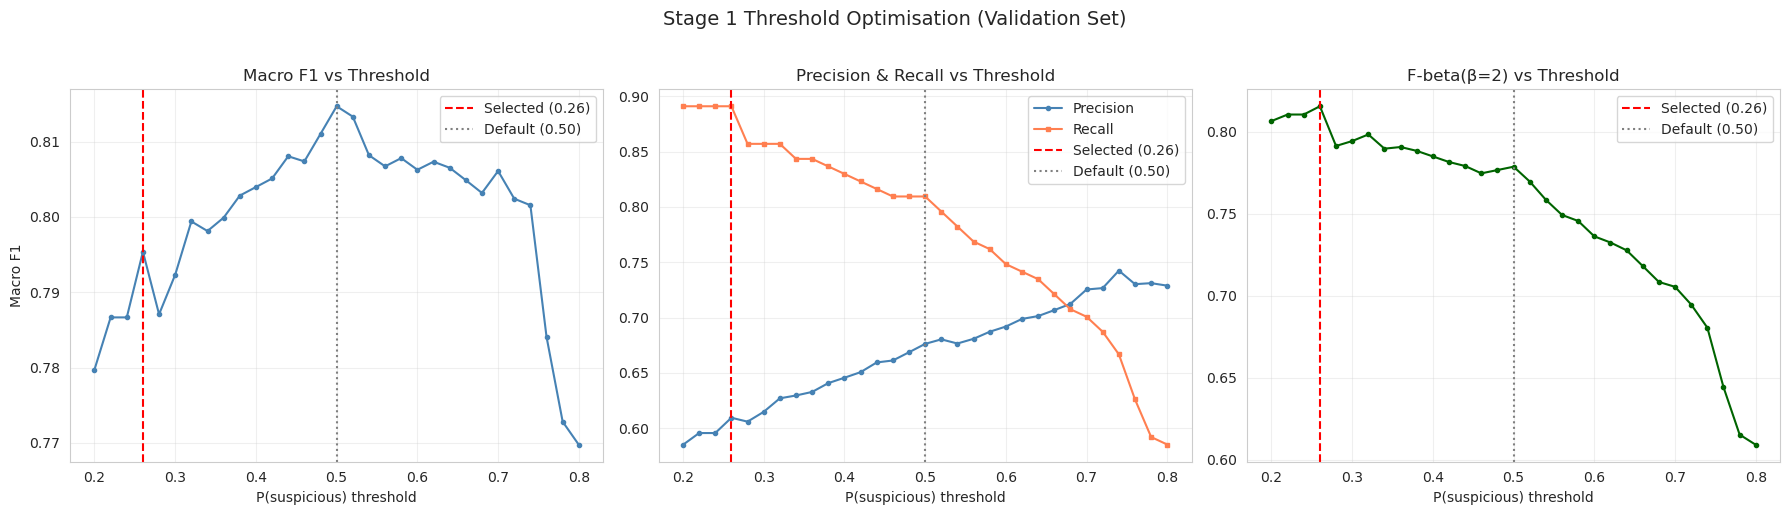

In [15]:
# Threshold sweep visualisation

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Plot 1: Macro F1 vs threshold
axes[0].plot(res_df['threshold'], res_df['macro_f1'], 'o-', color='steelblue', ms=3)
axes[0].axvline(OPTIMAL_THRESHOLD, color='red', ls='--', label=f'Selected ({OPTIMAL_THRESHOLD:.2f})')
axes[0].axvline(0.50, color='gray', ls=':', label='Default (0.50)')
axes[0].set_title('Macro F1 vs Threshold')
axes[0].set_xlabel('P(suspicious) threshold')
axes[0].set_ylabel('Macro F1')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Plot 2: Precision and Recall vs threshold
axes[1].plot(res_df['threshold'], res_df['precision'], 'o-', color='steelblue', ms=3, label='Precision')
axes[1].plot(res_df['threshold'], res_df['recall'], 's-', color='coral', ms=3, label='Recall')
axes[1].axvline(OPTIMAL_THRESHOLD, color='red', ls='--', label=f'Selected ({OPTIMAL_THRESHOLD:.2f})')
axes[1].axvline(0.50, color='gray', ls=':', label='Default (0.50)')
axes[1].set_title('Precision & Recall vs Threshold')
axes[1].set_xlabel('P(suspicious) threshold')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

# Plot 3: F-beta(2) vs threshold
axes[2].plot(res_df['threshold'], res_df['f_beta2'], 'o-', color='darkgreen', ms=3)
axes[2].axvline(OPTIMAL_THRESHOLD, color='red', ls='--', label=f'Selected ({OPTIMAL_THRESHOLD:.2f})')
axes[2].axvline(0.50, color='gray', ls=':', label='Default (0.50)')
axes[2].set_title('F-beta(β=2) vs Threshold')
axes[2].set_xlabel('P(suspicious) threshold')
axes[2].legend()
axes[2].grid(True, alpha=0.3)

plt.suptitle('Stage 1 Threshold Optimisation (Validation Set)', fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'v9_threshold_sweep.png'), dpi=150, bbox_inches='tight')
plt.show()

### Stage 1 - Test Evaluation (at both thresholds)


  Stage 1 TEST — Default (0.50)
  Accuracy: 0.8504
  Macro F1: 0.8124

              precision    recall  f1-score   support

      normal      0.886     0.908     0.897       412
  suspicious      0.752     0.706     0.728       163

    accuracy                          0.850       575
   macro avg      0.819     0.807     0.812       575
weighted avg      0.848     0.850     0.849       575



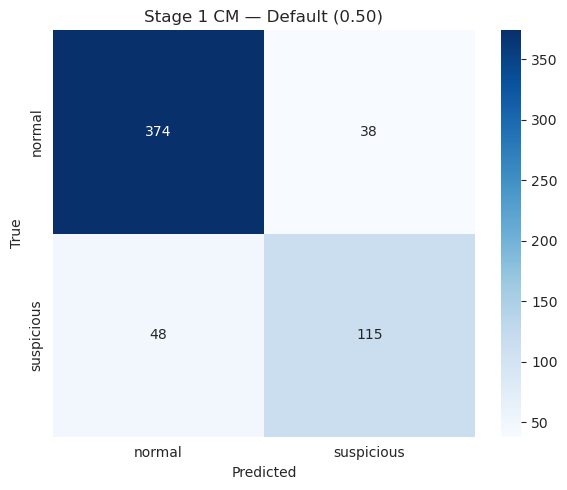


  Stage 1 TEST — Optimal (0.26)
  Accuracy: 0.8452
  Macro F1: 0.8151

              precision    recall  f1-score   support

      normal      0.909     0.871     0.890       412
  suspicious      0.706     0.779     0.741       163

    accuracy                          0.845       575
   macro avg      0.807     0.825     0.815       575
weighted avg      0.851     0.845     0.847       575



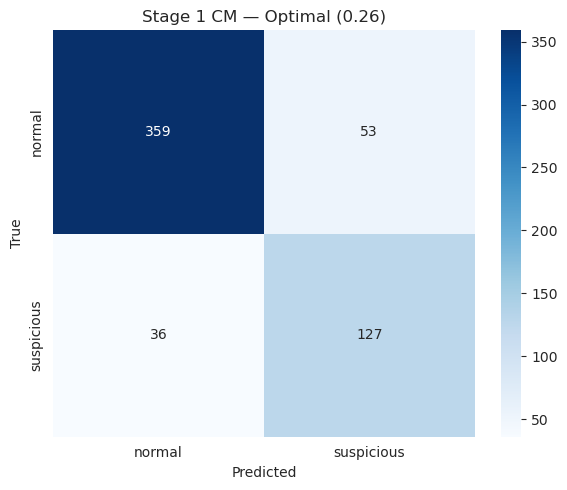

In [16]:
# Stage 1 test evaluation at default and optimal thresholds

for thr_name, thr_val in [('Default (0.50)', 0.50), (f'Optimal ({OPTIMAL_THRESHOLD:.2f})', OPTIMAL_THRESHOLD)]:
    preds = (p_sus_te >= thr_val).astype(int)
    acc = accuracy_score(test_trues, preds)
    f1 = f1_score(test_trues, preds, average='macro', zero_division=0)
    print(f'\n{"="*60}')
    print(f'  Stage 1 TEST — {thr_name}')
    print(f'{"="*60}')
    print(f'  Accuracy: {acc:.4f}')
    print(f'  Macro F1: {f1:.4f}')
    print(f'\n{classification_report(test_trues, preds, target_names=le1.classes_, digits=3, zero_division=0)}')

    cm = confusion_matrix(test_trues, preds)
    fig, ax = plt.subplots(figsize=(6, 5))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=le1.classes_, yticklabels=le1.classes_, ax=ax)
    ax.set_title(f'Stage 1 CM — {thr_name}'); ax.set_ylabel('True'); ax.set_xlabel('Predicted')
    plt.tight_layout()
    plt.savefig(os.path.join(OUTPUT_DIR, f'v9_stage1_cm_{thr_name.split("(")[0].strip().lower()}.png'), dpi=150, bbox_inches='tight')
    plt.show()

---

## 10. Stage 2 - 3-Class Merged Suspicious Subtype Classifier


In [17]:
# Prepare Stage 2 data (suspicious windows only, merged classes)
sus_mask = all_labels_2 == 'suspicious'
X2_all   = all_features[sus_mask]
y2_str   = all_labels_merged[sus_mask]  # Already merged: head_turn, lateral_movement, looking_down

le2 = LabelEncoder()
le2.fit(MERGED_SUSPICIOUS)
y2_all = le2.transform(y2_str)

# Apply scenario split to suspicious subset
meta_df_sus = pd.DataFrame([m for m, s in zip(all_meta, sus_mask) if s])
sids_sus = meta_df_sus['scenario_id'].values
tr2 = np.isin(sids_sus, list(train_scenarios))
va2 = np.isin(sids_sus, list(val_scenarios))
te2 = np.isin(sids_sus, list(test_scenarios))

sc2 = StandardScaler()
X2_tr = sc2.fit_transform(X2_all[tr2]).astype(np.float32)
X2_va = sc2.transform(X2_all[va2]).astype(np.float32)
X2_te = sc2.transform(X2_all[te2]).astype(np.float32)
y2_tr, y2_va, y2_te = y2_all[tr2], y2_all[va2], y2_all[te2]

save_ckpt(sc2, S2_SCALER_PATH)

print(f'\nStage 2 — {NUM_MERGED_SUS}-class merged suspicious')
print(f'  Train: {len(X2_tr)},  Val: {len(X2_va)},  Test: {len(X2_te)}')
print(f'\n  Train distribution:')
for i, name in enumerate(le2.classes_):
    n = int((y2_tr == i).sum())
    originals = MERGE_REVERSE.get(name, [name])
    print(f'    {name:<20s} {n:4d}  (from: {originals})')

# Balanced sampler
cc2 = np.bincount(y2_tr, minlength=NUM_MERGED_SUS).astype(np.float64)
sw2 = (1.0 / np.maximum(cc2, 1))[y2_tr]
sw2 = sw2 / sw2.sum()
sampler2 = WeightedRandomSampler(sw2, len(sw2), replacement=True)

dl2_tr = DataLoader(TensorDataset(torch.FloatTensor(X2_tr), torch.LongTensor(y2_tr)), batch_size=BS, sampler=sampler2)
dl2_va = DataLoader(TensorDataset(torch.FloatTensor(X2_va), torch.LongTensor(y2_va)), batch_size=BS, shuffle=False)
dl2_te = DataLoader(TensorDataset(torch.FloatTensor(X2_te), torch.LongTensor(y2_te)), batch_size=BS, shuffle=False)

  Saved: stage2_scaler_v9.pkl (2.3 KB)

Stage 2 — 3-class merged suspicious
  Train: 732,  Val: 147,  Test: 163

  Train distribution:
    head_turn             345  (from: ['looking_sideways', 'talking_to_neighbor'])
    lateral_movement      265  (from: ['leaning_to_neighbor', 'passing_note'])
    looking_down          122  (from: ['looking_down'])


In [18]:
# Train Stage 2 (3-class)

print('=' * 60)
print(f'  STAGE 2: {NUM_MERGED_SUS}-Class Merged Suspicious Subtype')
print('=' * 60)

model2 = Classifier(NUM_FEATURES, H1, H2, NUM_MERGED_SUS, DROP).to(device)
print(f'  Parameters: {sum(p.numel() for p in model2.parameters()):,}')
print(f'  Classes: {list(le2.classes_)}\n')

hist2, best_f1_s2 = train_model(model2, dl2_tr, dl2_va, NUM_MERGED_SUS, S2_MODEL_PATH)

  STAGE 2: 3-Class Merged Suspicious Subtype
  Parameters: 18,975
  Classes: ['head_turn', 'lateral_movement', 'looking_down']

  Ep   1/150  loss=1.0544/1.0169  F1=0.4258/0.6454  lr=1.0e-03  ★
  Ep   2/150  loss=0.8672/0.9141  F1=0.6269/0.6865  lr=1.0e-03  ★
  Ep   4/150  loss=0.6125/0.7164  F1=0.7836/0.7327  lr=1.0e-03  ★
  Ep   8/150  loss=0.3565/0.5566  F1=0.8733/0.7822  lr=1.0e-03  ★
  Ep  10/150  loss=0.2959/0.5926  F1=0.8889/0.7494  lr=1.0e-03
  Ep  14/150  loss=0.2676/0.5926  F1=0.8969/0.8040  lr=1.0e-03  ★
  Ep  20/150  loss=0.2211/0.6579  F1=0.9169/0.7588  lr=1.0e-03
  Ep  30/150  loss=0.1271/0.7157  F1=0.9602/0.7715  lr=5.0e-04
  Early stopping at epoch 39
  Best val F1: 0.8040


### Stage 2 - Training Curves

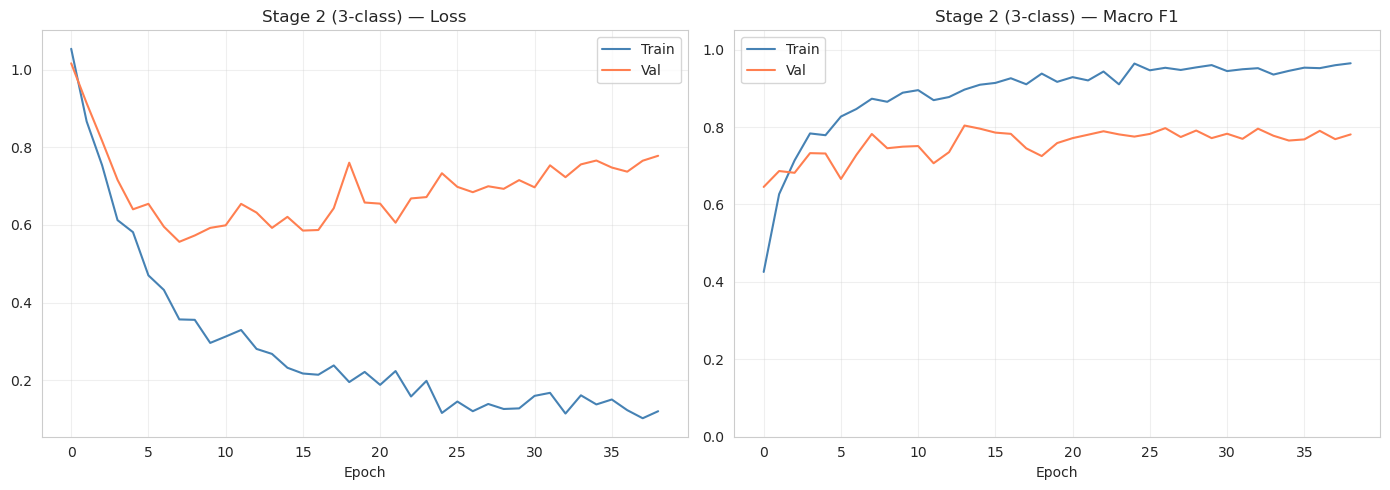

In [19]:
plot_curves(hist2, 'Stage 2 (3-class)', 'v9_stage2_curves.png')

### Stage 2 - Test Evaluation

Loaded Stage 2 from epoch 14 (val F1 = 0.8040)

  STAGE 2 TEST — 3-class merged
  Accuracy: 0.7362
  Macro F1: 0.7451

                  precision    recall  f1-score   support

       head_turn      0.820     0.714     0.763        70
lateral_movement      0.656     0.667     0.661        60
    looking_down      0.732     0.909     0.811        33

        accuracy                          0.736       163
       macro avg      0.736     0.763     0.745       163
    weighted avg      0.742     0.736     0.735       163



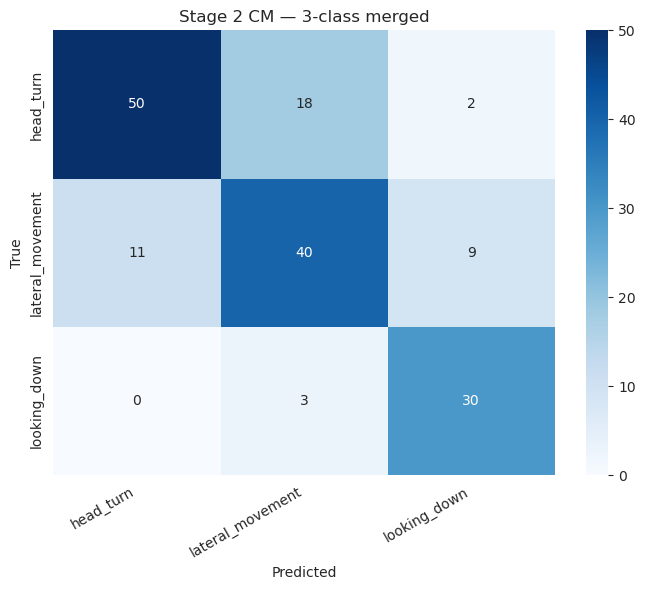

In [20]:
# Stage 2 test evaluation

ckpt2 = torch.load(S2_MODEL_PATH, map_location=device, weights_only=True)
model2.load_state_dict(ckpt2['state_dict'])
print(f'Loaded Stage 2 from epoch {ckpt2["epoch"]+1} (val F1 = {ckpt2["val_f1"]:.4f})')

model2.eval()
p2, t2 = [], []
with torch.no_grad():
    for xb, yb in dl2_te:
        out = model2(xb.to(device))
        p2.extend(out.argmax(1).cpu().numpy())
        t2.extend(yb.numpy())
p2, t2 = np.array(p2), np.array(t2)

print(f'\n{"="*60}')
print(f'  STAGE 2 TEST — {NUM_MERGED_SUS}-class merged')
print(f'{"="*60}')
print(f'  Accuracy: {accuracy_score(t2, p2):.4f}')
print(f'  Macro F1: {f1_score(t2, p2, average="macro"):.4f}')
print(f'\n{classification_report(t2, p2, target_names=le2.classes_, digits=3, zero_division=0)}')

cm2 = confusion_matrix(t2, p2, labels=np.arange(NUM_MERGED_SUS))
fig, ax = plt.subplots(figsize=(7, 6))
sns.heatmap(cm2, annot=True, fmt='d', cmap='Blues', xticklabels=le2.classes_, yticklabels=le2.classes_, ax=ax)
ax.set_title(f'Stage 2 CM — {NUM_MERGED_SUS}-class merged')
ax.set_ylabel('True'); ax.set_xlabel('Predicted')
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'v9_stage2_cm.png'), dpi=150, bbox_inches='tight')
plt.show()

---

## 11. Combined Pipeline Evaluation


In [21]:
# Combined pipeline evaluation function

le_merged = LabelEncoder()
le_merged.fit(ALL_MERGED_CLASSES)
y_merged_te = le_merged.transform(all_labels_merged[te_m])


def evaluate_combined(threshold, label=''):
    """Run and evaluate the full two-stage pipeline at a given threshold."""

    # Stage 1: flag windows above threshold
    flagged = p_sus_te >= threshold
    n_flagged = int(flagged.sum())

    # Start with all predictions as normal
    normal_idx = le_merged.transform(['normal'])[0]
    combined = np.full(len(p_sus_te), normal_idx)

    # Stage 2: classify flagged windows
    if n_flagged > 0:
        X_flag = sc2.transform(all_features[te_m][flagged]).astype(np.float32)
        model2.eval()
        s2p = []
        with torch.no_grad():
            for start in range(0, len(X_flag), BS):
                xb = torch.FloatTensor(X_flag[start:start+BS]).to(device)
                s2p.extend(model2(xb).argmax(1).cpu().numpy())

        flag_indices = np.where(flagged)[0]
        for i, fi in enumerate(flag_indices):
            cls_name = le2.classes_[s2p[i]]
            combined[fi] = le_merged.transform([cls_name])[0]

    acc = accuracy_score(y_merged_te, combined)
    f1  = f1_score(y_merged_te, combined, average='macro', zero_division=0)

    print(f'\n{"="*60}')
    print(f'  COMBINED PIPELINE — {label} (threshold={threshold:.2f})')
    print(f'{"="*60}')
    print(f'  Stage 1 flagged: {n_flagged} / {len(p_sus_te)} ({n_flagged/len(p_sus_te)*100:.1f}%)')
    print(f'  Accuracy:  {acc:.4f}')
    print(f'  Macro F1:  {f1:.4f}')
    print(f'\n{classification_report(y_merged_te, combined, target_names=le_merged.classes_, digits=3, zero_division=0)}')

    return combined, acc, f1


# Evaluate at both thresholds
combined_default, acc_default, f1_default = evaluate_combined(DEFAULT_THRESHOLD, 'Default')
combined_optimal, acc_optimal, f1_optimal = evaluate_combined(OPTIMAL_THRESHOLD, 'Optimal')


  COMBINED PIPELINE — Default (threshold=0.50)
  Stage 1 flagged: 153 / 575 (26.6%)
  Accuracy:  0.8000
  Macro F1:  0.6303

                  precision    recall  f1-score   support

       head_turn      0.583     0.500     0.538        70
lateral_movement      0.579     0.550     0.564        60
    looking_down      0.500     0.545     0.522        33
          normal      0.886     0.908     0.897       412

        accuracy                          0.800       575
       macro avg      0.637     0.626     0.630       575
    weighted avg      0.795     0.800     0.797       575


  COMBINED PIPELINE — Optimal (threshold=0.26)
  Stage 1 flagged: 180 / 575 (31.3%)
  Accuracy:  0.7878
  Macro F1:  0.6340

                  precision    recall  f1-score   support

       head_turn      0.521     0.543     0.531        70
lateral_movement      0.537     0.600     0.567        60
    looking_down      0.500     0.606     0.548        33
          normal      0.909     0.871     0.890 

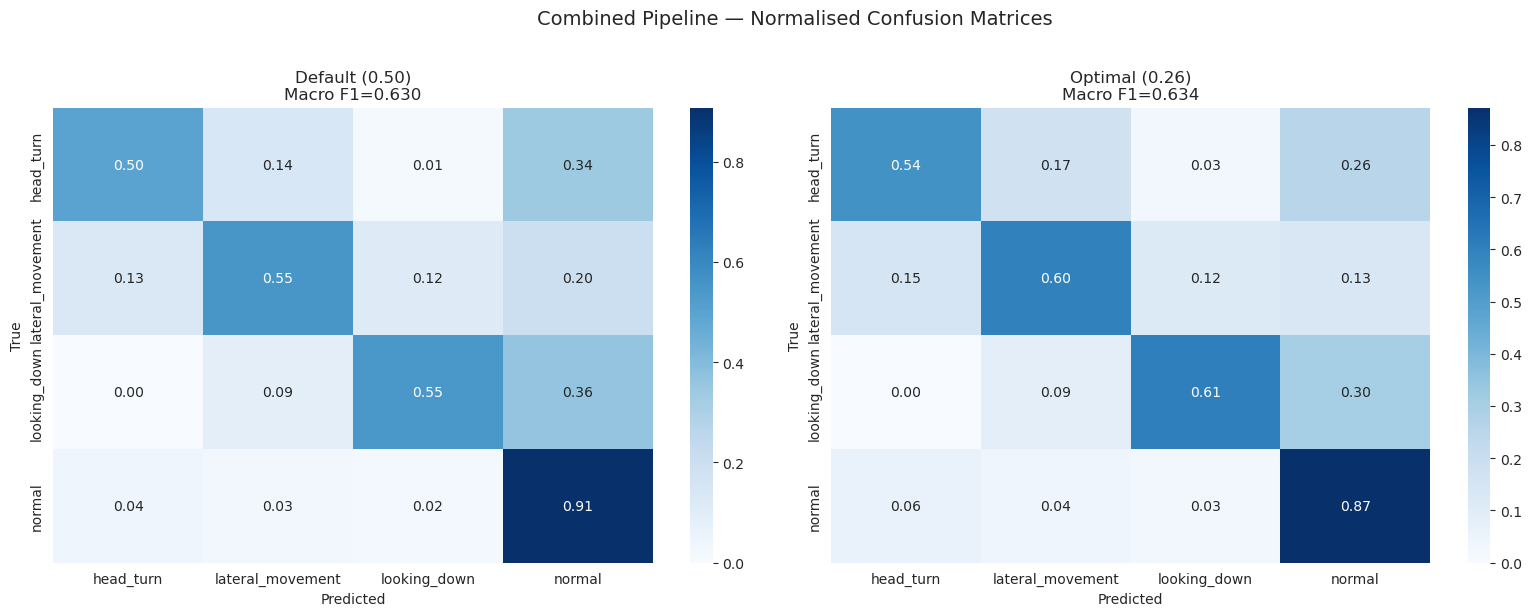

In [22]:
# ---------------------------------------------------------------------------
# 11b. Side-by-side confusion matrices
# ---------------------------------------------------------------------------

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

for ax, preds, thr_name, thr_val in [
    (axes[0], combined_default, 'Default (0.50)', DEFAULT_THRESHOLD),
    (axes[1], combined_optimal, f'Optimal ({OPTIMAL_THRESHOLD:.2f})', OPTIMAL_THRESHOLD),
]:
    cm = confusion_matrix(y_merged_te, preds, labels=np.arange(len(ALL_MERGED_CLASSES)))
    cm_n = cm.astype(float) / np.maximum(cm.sum(axis=1, keepdims=True), 1)
    sns.heatmap(cm_n, annot=True, fmt='.2f', cmap='Blues',
                xticklabels=le_merged.classes_, yticklabels=le_merged.classes_, ax=ax)
    f1 = f1_score(y_merged_te, preds, average='macro', zero_division=0)
    ax.set_title(f'{thr_name}\nMacro F1={f1:.3f}')
    ax.set_ylabel('True'); ax.set_xlabel('Predicted')

plt.suptitle('Combined Pipeline — Normalised Confusion Matrices', fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'v9_combined_cm_comparison.png'), dpi=150, bbox_inches='tight')
plt.show()

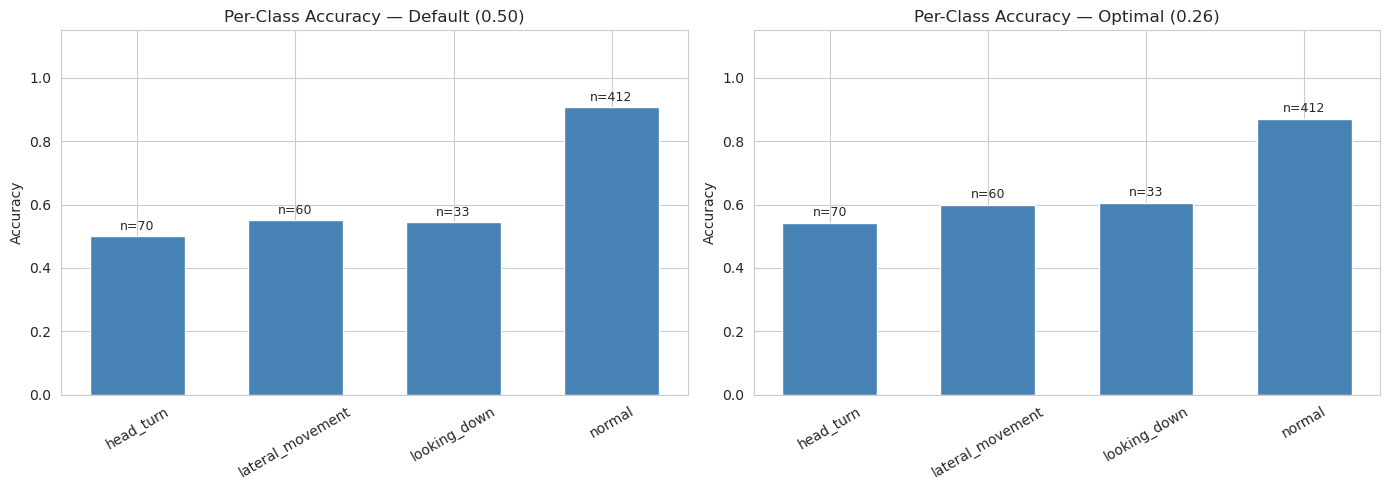

In [23]:
# Per-class accuracy comparison

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, preds, thr_name in [
    (axes[0], combined_default, 'Default (0.50)'),
    (axes[1], combined_optimal, f'Optimal ({OPTIMAL_THRESHOLD:.2f})'),
]:
    cls_data = []
    for i, name in enumerate(le_merged.classes_):
        mask = y_merged_te == i
        if mask.sum() > 0:
            cls_data.append((name, float((preds[mask] == i).mean()), int(mask.sum())))
    names, accs, counts = zip(*cls_data)
    bars = ax.bar(names, accs, color='steelblue', edgecolor='white', width=0.6)
    for b, c in zip(bars, counts):
        ax.text(b.get_x() + b.get_width()/2, b.get_height() + 0.02, f'n={c}', ha='center', fontsize=9)
    ax.set_title(f'Per-Class Accuracy — {thr_name}')
    ax.set_ylim(0, 1.15); ax.set_ylabel('Accuracy')
    ax.tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'v9_per_class_accuracy_comparison.png'), dpi=150, bbox_inches='tight')
plt.show()

---

## 12. v8 vs v9 Comparison Summary


In [24]:
# Comparison summary

print(f'\n{"═"*60}')
print(f'  v8 vs v9 COMPARISON')
print(f'{"═"*60}')
print(f'')
print(f'  {"Metric":<35s} {"v8":>8s} {"v9 (opt)":>10s}')
print(f'  {"─"*55}')
print(f'  {"Stage 1 best val F1":<35s} {"0.8130":>8s} {best_f1_s1:>10.4f}')
print(f'  {"Stage 2 best val F1":<35s} {"0.6562":>8s} {best_f1_s2:>10.4f}')
print(f'  {"Stage 2 classes":<35s} {"5":>8s} {NUM_MERGED_SUS:>10d}')
print(f'  {"Stage 1 threshold":<35s} {"0.50":>8s} {OPTIMAL_THRESHOLD:>10.2f}')
print(f'  {"Combined test accuracy":<35s} {"0.7565":>8s} {acc_optimal:>10.4f}')
print(f'  {"Combined test macro F1":<35s} {"0.4738":>8s} {f1_optimal:>10.4f}')
print(f'  {"Suspicious recall (Stage 1)":<35s} {"0.583":>8s} ', end='')

# Compute Stage 1 recall at optimal threshold
s1_opt_preds = (p_sus_te >= OPTIMAL_THRESHOLD).astype(int)
s1_opt_recall = float((s1_opt_preds[test_trues == 1] == 1).sum()) / max(float((test_trues == 1).sum()), 1)
print(f'{s1_opt_recall:>10.3f}')


════════════════════════════════════════════════════════════
  v8 vs v9 COMPARISON
════════════════════════════════════════════════════════════

  Metric                                    v8   v9 (opt)
  ───────────────────────────────────────────────────────
  Stage 1 best val F1                   0.8130     0.8147
  Stage 2 best val F1                   0.6562     0.8040
  Stage 2 classes                            5          3
  Stage 1 threshold                       0.50       0.26
  Combined test accuracy                0.7565     0.7878
  Combined test macro F1                0.4738     0.6340
  Suspicious recall (Stage 1)            0.583      0.779


---

## 13. Export Inference Package

The v9 inference package includes everything needed for live deployment:

- Both model weights
- Both scalers (serialised as bytes)
- The optimal Stage 1 threshold
- The class merge mapping (so Phase 4 knows how to interpret predictions)
- Architecture config, feature names, and performance metrics

In [25]:
#  Export inference package

pkg = {
    # ── Model weights ──
    'stage1_state_dict': model1.state_dict(),
    'stage2_state_dict': model2.state_dict(),

    # ── Scalers ──
    'stage1_scaler_bytes': scaler_to_bytes(sc1),
    'stage2_scaler_bytes': scaler_to_bytes(sc2),

    # ── Stage 1 threshold ──
    'stage1_threshold': OPTIMAL_THRESHOLD,
    'stage1_default_threshold': DEFAULT_THRESHOLD,

    # ── Architecture config ──
    'model_config': {
        'input_dim':   NUM_FEATURES,
        'hidden1':     H1,
        'hidden2':     H2,
        'dropout':     DROP,
        'stage1_out':  2,
        'stage2_out':  NUM_MERGED_SUS,
    },

    # ── Class mappings ──
    'stage1_classes':          ['normal', 'suspicious'],
    'stage2_classes':          list(le2.classes_),        # 3 merged suspicious classes
    'all_classes':             ALL_MERGED_CLASSES,        # 4 classes: normal + 3 merged
    'merge_map':               MERGE_MAP,                 # original → merged mapping
    'merge_reverse':           MERGE_REVERSE,             # merged → [originals]

    # ── Feature config ──
    'feature_names':           FEAT_NAMES,
    'full_feature_names':      FULL_FEAT_NAMES,
    'window_size_sec':         3.0,
    'window_stride_sec':       1.0,
    'min_visibility':          0.5,

    # ── Performance metrics ──
    'test_accuracy_default':   float(acc_default),
    'test_macro_f1_default':   float(f1_default),
    'test_accuracy_optimal':   float(acc_optimal),
    'test_macro_f1_optimal':   float(f1_optimal),
    'stage1_best_val_f1':      float(best_f1_s1),
    'stage2_best_val_f1':      float(best_f1_s2),
}

torch.save(pkg, INFERENCE_PKG_PATH)
pkg_size = os.path.getsize(INFERENCE_PKG_PATH) / 1024

# Verification
verify = torch.load(INFERENCE_PKG_PATH, map_location='cpu', weights_only=False)
sc1_v = pickle.loads(verify['stage1_scaler_bytes'])
sc2_v = pickle.loads(verify['stage2_scaler_bytes'])
print(f'\nInference package: {INFERENCE_PKG_PATH} ({pkg_size:.1f} KB)')
print(f'  Verification: scalers OK (sc1={sc1_v.mean_.shape}, sc2={sc2_v.mean_.shape})')
print(f'  Threshold stored: {verify["stage1_threshold"]:.2f}')
print(f'  Merge map stored: {verify["merge_map"]}')


Inference package: /home/sagemaker-user/exam_proctoring_dataset/training_outputs/inference_package_v9.pth (172.6 KB)
  Verification: scalers OK (sc1=(78,), sc2=(78,))
  Threshold stored: 0.26
  Merge map stored: {'normal': 'normal', 'looking_down': 'looking_down', 'leaning_to_neighbor': 'lateral_movement', 'passing_note': 'lateral_movement', 'looking_sideways': 'head_turn', 'talking_to_neighbor': 'head_turn'}
